<a href="https://colab.research.google.com/github/Pramit44/Alfido-Tech-Data-Science-Internship-Project/blob/main/Alfido_Tech_Instagram_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [167]:
follows = pd.read_csv("/content/drive/MyDrive/DataScience Projects/kaggle/follows.csv")
follows.head()

,follower,followee,created time,is follower active,followee Acc status
0,2,1,13-04-2023 08:04,1,Private
1,2,3,13-04-2023 08:04,0,private
2,2,4,13-04-2023 08:04,0,public
3,2,5,13-04-2023 08:04,0,private
4,2,6,13-04-2023 08:04,1,private


In [168]:
follows.columns = follows.columns.str.strip()

In [169]:
follower_count=follows.groupby('followee')["follower"].count()
display(follower_count.head())

,follower
followee,
1,77
2,76
3,76
4,76
5,76


In [170]:
likes=pd.read_csv("/content/drive/MyDrive/DataScience Projects/kaggle/likes.csv")
likes.tail()

,user,photo,created time,following or not,like type
8777,100,245,13-04-2023 08:04,no,clap
8778,100,246,13-04-2023 08:04,yes,heart emoji
8779,100,248,13-04-2023 08:04,yes,thumbs up
8780,100,249,13-04-2023 08:04,no,laughing
8781,100,255,13-04-2023 08:04,yes,fire


In [171]:
likes.columns = likes.columns.str.strip()

In [172]:
like_count=likes.groupby('photo')["user"].count()
display(like_count.head())

,user
photo,
1,25
2,36
3,38
4,38
5,31


In [173]:
comment=pd.read_csv('/content/drive/MyDrive/DataScience Projects/kaggle/comments.csv')
comment.head()

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [174]:
comment_count=comment.groupby('Photo id')["comment"].count()
display(comment_count.head())

,comment
Photo id,
1,25
2,31
3,27
4,32
5,27


In [175]:
photos=pd.read_csv("/content/drive/MyDrive/DataScience Projects/kaggle/photos.csv")
photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo


In [176]:
df = photos.copy()

In [177]:
df = df.merge(like_count, left_on='id', right_on='photo', how='left')

In [178]:
df = df.merge(comment_count, left_on='id', right_on='Photo id', how='left')

In [179]:
df = df.merge(follower_count, left_on='user ID', right_on='followee', how='left')
df = df.rename(columns={'user': 'like_count', 'comment': 'comment_count', 'follower': 'follower_count'})

In [219]:
tags=tags_df = pd.read_csv("/content/drive/MyDrive/DataScience Projects/kaggle/tags.csv")

In [220]:
merged_df = pd.merge(df, tags_df, left_on='id', right_on='id', how='inner')

In [221]:
top_tags = merged_df.groupby('tag text')['engagement_rate'].mean().sort_values(ascending=False).reset_index()

In [222]:
print(top_tags.head(5))

      tag text  engagement_rate
0          fun       103.947368
1    landscape        90.909091
2        drunk        90.789474
3  photography        87.012987
4       beauty        85.526316


In [223]:
top_locations = merged_df.groupby('location')['engagement_rate'].mean().sort_values(ascending=False).reset_index()

In [224]:
print(top_locations.head(5))

    location  engagement_rate
0     brazil        89.636022
1  australia        85.526316
2   new york        84.717476
3     Mumbai        83.552632
4     london        81.618820


/tmp/ipykernel_618/1784764958.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tag text', y='engagement_rate', data=top_tags.head(5), palette='flare')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'fun'),
  Text(1, 0, 'landscape'),
  Text(2, 0, 'drunk'),
  Text(3, 0, 'photography'),
  Text(4, 0, 'beauty')])

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


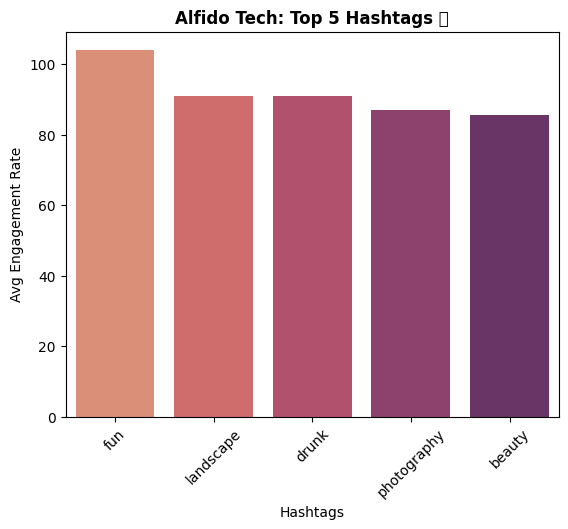

In [226]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='tag text', y='engagement_rate', data=top_tags.head(5), palette='flare')
plt.title('Alfido Tech: Top 5 Hashtags 🔥', fontweight='bold')
plt.ylabel('Avg Engagement Rate')
plt.xlabel('Hashtags')
plt.xticks(rotation=45)

/tmp/ipykernel_618/1153617002.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='location', y='engagement_rate', data=top_locations.head(5), palette='crest')
/tmp/ipykernel_618/1153617002.py:7: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


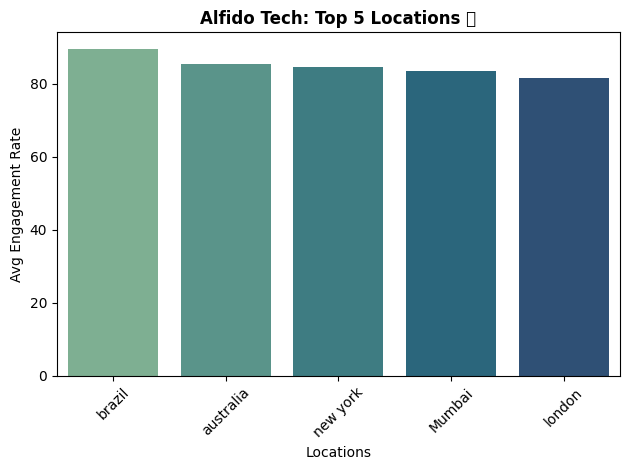

In [228]:
sns.barplot(x='location', y='engagement_rate', data=top_locations.head(5), palette='crest')
plt.title('Alfido Tech: Top 5 Locations 📍', fontweight='bold')
plt.ylabel('Avg Engagement Rate')
plt.xlabel('Locations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [182]:
df['total_engagement'] = df['like_count'].fillna(0) + df['comment_count'].fillna(0)

In [183]:
df['engagement_rate'] = (df['total_engagement'] / df['follower_count'].fillna(0).replace(0, 1)) * 100

In [186]:
print(df[['id', 'like_count', 'comment_count', 'total_engagement', 'engagement_rate']].head())

   id  like_count  comment_count  total_engagement  engagement_rate
0   1          25             25                50        64.935065
1   2          36             31                67        87.012987
2   3          38             27                65        84.415584
3   4          38             32                70        90.909091
4   5          31             27                58        75.324675


In [187]:
top_5_posts = df.sort_values(by='engagement_rate', ascending=False).head(5)

In [189]:
print("TOP 5 VIRAL POSTS")
print(top_5_posts[['id', 'like_count', 'comment_count', 'engagement_rate']])

TOP 5 VIRAL POSTS
      id  like_count  comment_count  engagement_rate
12    13          40             39       103.947368
144  145          48             27        98.684211
146  147          41             34        98.684211
117  118          39             35        97.368421
226  227          39             35        97.368421


In [190]:
avg_engagement = df['engagement_rate'].mean()
print(f" Alfido Tech ka Average Engagement Rate: {avg_engagement:.2f}%")

 Alfido Tech ka Average Engagement Rate: 82.97%


In [204]:
df['created dat'] = pd.to_datetime(df['created dat'], format='mixed', dayfirst=True)

In [203]:
df['post_day'] = df['created dat'].dt.day_name()

In [202]:
df['post_hour'] = df['created dat'].dt.hour

In [201]:
best_day = df.groupby('post_day')['engagement_rate'].mean().sort_values(ascending=False).reset_index()

In [198]:
best_hour = df.groupby('post_hour')['engagement_rate'].mean().sort_values(ascending=False).reset_index()

In [205]:
print(best_day.head(3))

   post_day  engagement_rate
0  Thursday        82.969273


In [200]:
print(best_hour.head(3))

   post_hour  engagement_rate
0          8        82.969273


/tmp/ipykernel_618/1239410209.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='post_day', y='engagement_rate', data=best_day, palette='Blues_r')


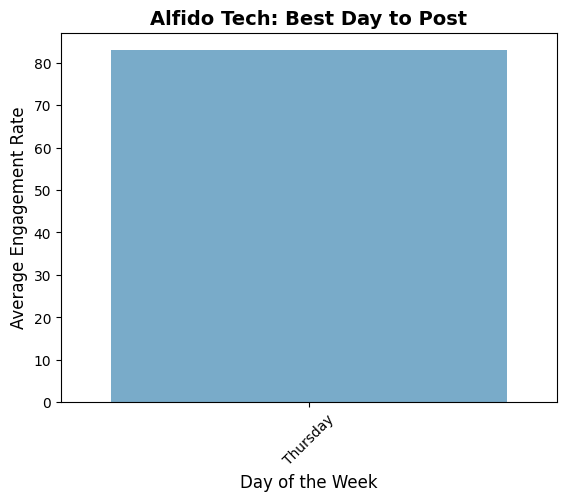

In [210]:
sns.barplot(x='post_day', y='engagement_rate', data=best_day, palette='Blues_r')
plt.title('Alfido Tech: Best Day to Post', fontsize=14, fontweight='bold')
plt.ylabel('Average Engagement Rate', fontsize=12)
plt.xlabel('Day of the Week', fontsize=12)
plt.xticks(rotation=45) # Labels thode teedhe kar diye taaki overlap na ho
plt.show()